In [ ]:
import gc
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_ind

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = '/content/drive/MyDrive/jan-2025.csv'

buy_codes = [1, 2, 3, 5]
sell_codes = [4, 8, 10, 11]
cols = ['SUB_ACC', 'ISIN', 'TR_TYPE(*)', 'QUANTITY', 'VALUE (in Rs)']
min_trades = 20
alphas = np.round(np.arange(0, 1.1, 0.1), 2)
n_sims = 10

In [ ]:
df = pd.read_csv(filepath, usecols=cols)

In [ ]:
# Filtering only valid transactions
df = df[df['TR_TYPE(*)'].isin(buy_codes + sell_codes)].copy()
df = df.dropna(subset=['SUB_ACC'])
df = df[df['SUB_ACC'].str.strip() != '']

df['SIDE'] = 'SELL'
df.loc[df['TR_TYPE(*)'].isin(buy_codes), 'SIDE'] = 'BUY'

buy_pos = df[df['SIDE']=='BUY'].groupby(['SUB_ACC','ISIN'])[['VALUE (in Rs)','QUANTITY']].sum()
buy_pos.columns = ['BUY_VAL', 'BUY_QTY']
buy_pos = buy_pos.reset_index()

sell_pos = df[df['SIDE']=='SELL'].groupby(['SUB_ACC','ISIN'])[['VALUE (in Rs)','QUANTITY']].sum()
sell_pos.columns = ['SELL_VAL', 'SELL_QTY']
sell_pos = sell_pos.reset_index()

# Keeping only the stocks where both buy and sell exist
pos = pd.merge(buy_pos, sell_pos, on=['SUB_ACC','ISIN'])
pos = pos[(pos['BUY_QTY']>0) & (pos['SELL_QTY']>0)].copy()
pos['AVG_BUY'] = pos['BUY_VAL'] / pos['BUY_QTY']
pos['AVG_SELL'] = pos['SELL_VAL'] / pos['SELL_QTY']
pos['WIN'] = (pos['AVG_SELL'] > pos['AVG_BUY']).astype(int)

trade_count = df.groupby('SUB_ACC').size().reset_index(name='TRADE_COUNT')
valid_users = trade_count[trade_count['TRADE_COUNT'] >= min_trades]['SUB_ACC']
pos = pos[pos['SUB_ACC'].isin(valid_users)].copy()

pos[['SUB_ACC','ISIN','AVG_BUY','AVG_SELL','WIN']].head()

,SUB_ACC,ISIN,AVG_BUY,AVG_SELL,WIN
0,S1000238085476,INE00H001014,433.118900,418.158300,0
1,S1000238085476,INE758T01015,216.376400,224.950574,1
2,S1001458825855,INE010J01012,1069.690385,888.274943,0
3,S1001811484187,INE003A01024,6071.422200,5827.877000,0
4,S1001811484187,INE009A01021,1933.997886,1864.442171,0


In [ ]:
# Baseline win rate per user (no dilution)

user_wr_baseline = pos['WIN'].mean()

print('Mean WR:', round(user_wr_baseline, 4))
print('Median WR:', round(user_wr['USER_WR'].median(), 4))

Mean WR: 0.492
Median WR: 0.4


In [ ]:
np.random.seed(42)

results = []

for alpha in alphas:

    # For each alpha, run n_sims flips and average the diluted WR
    sim_wrs = []
    for _ in range(n_sims):
        pos_sim = pos.copy()
        flip_mask = np.random.rand(len(pos_sim)) < alpha
        pos_sim.loc[flip_mask, 'WIN'] = 1 - pos_sim.loc[flip_mask, 'WIN']

        sim_wr = pos_sim.groupby('SUB_ACC')['WIN'].agg(WINS='sum', TOTAL='count').reset_index()
        sim_wr['WR'] = sim_wr['WINS'] / sim_wr['TOTAL']
        sim_wrs.append(sim_wr.set_index('SUB_ACC')['WR'])

    avg_alpha_wr = pd.concat(sim_wrs, axis=1).mean(axis=1).reset_index()
    avg_alpha_wr.columns = ['SUB_ACC', 'ALPHA_RANDOM_WR']

    combined = pd.merge(user_wr[['SUB_ACC','USER_WR']], avg_alpha_wr, on='SUB_ACC')

    mw_stat, mw_pval = mannwhitneyu(combined['USER_WR'], combined['ALPHA_RANDOM_WR'], alternative='greater')
    t_stat, t_pval = ttest_ind(combined['USER_WR'], combined['ALPHA_RANDOM_WR'], equal_var=False, alternative='greater')

    diff = np.abs(combined['USER_WR'] - combined['ALPHA_RANDOM_WR'])

    results.append({
        'alpha': alpha,
        'mean_USER_WR': combined['USER_WR'].mean(),
        'mean_ALPHA_WR': combined['ALPHA_RANDOM_WR'].mean(),
        'mannwhitney_stat': mw_stat,
        'mannwhitney_pval': mw_pval,
        'mannwhitney_result': 'rejected' if mw_pval < 0.05 else 'fail to reject',
        'ttest_stat': t_stat,
        'ttest_pval': t_pval,
        'ttest_result': 'significant' if t_pval < 0.05 else 'insignificant',
        'mean_diff_wr': diff.mean(),
        'median_diff_wr': diff.median()
    })

results_df = pd.DataFrame(results)
results_df

,alpha,mean_USER_WR,mean_ALPHA_WR,mannwhitney_stat,mannwhitney_pval,mannwhitney_result,ttest_stat,ttest_pval,ttest_result,mean_diff_wr,median_diff_wr
0,0.0,0.422445,0.422445,251511.5,0.528162,fail to reject,0.000000,0.500000,insignificant,2.344564e-17,0.000000
1,0.1,0.422445,0.437740,238173.5,0.964149,fail to reject,-0.897948,0.815314,insignificant,6.755234e-02,0.050000
2,0.2,0.422445,0.456956,228311.5,0.998961,fail to reject,-2.189570,0.985628,insignificant,1.274416e-01,0.100000
3,0.3,0.422445,0.472657,218682.0,0.999992,fail to reject,-3.433304,0.999690,insignificant,1.940039e-01,0.181101
4,0.4,0.422445,0.481775,212552.0,1.000000,fail to reject,-4.234542,0.999987,insignificant,2.507559e-01,0.225000
5,0.5,0.422445,0.504333,200309.5,1.000000,fail to reject,-5.974448,1.000000,insignificant,3.111395e-01,0.300000
6,0.6,0.422445,0.511387,197392.0,1.000000,fail to reject,-6.374610,1.000000,insignificant,3.693335e-01,0.378889
7,0.7,0.422445,0.525246,193902.0,1.000000,fail to reject,-7.016310,1.000000,insignificant,4.291270e-01,0.423611
8,0.8,0.422445,0.547314,189840.5,1.000000,fail to reject,-8.009736,1.000000,insignificant,4.891134e-01,0.500000
9,0.9,0.422445,0.561084,189976.5,1.000000,fail to reject,-8.112841,1.000000,insignificant,5.516037e-01,0.573864


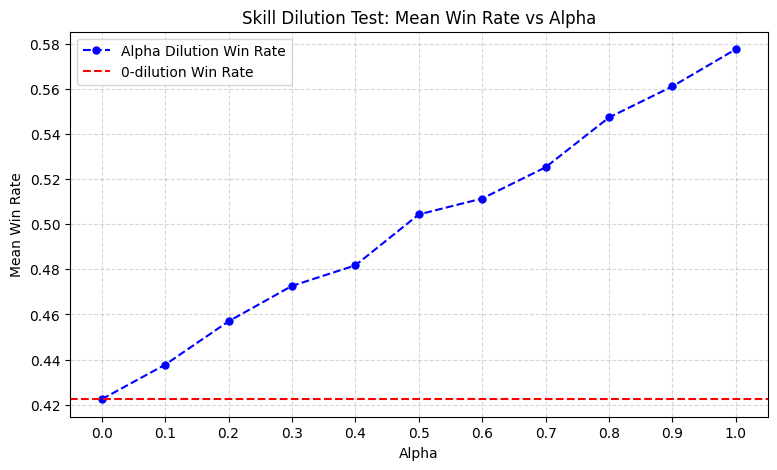

In [ ]:
# Mean win rate vs alpha
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(results_df['alpha'], results_df['mean_ALPHA_WR'], 'b--o', label='Alpha Dilution Win Rate', linewidth=1.5, markersize=5)

baseline = results_df.loc[results_df['alpha']==0.0, 'mean_USER_WR'].values[0]
ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5, label='0-dilution Win Rate')

ax.set_xlabel('Alpha')
ax.set_ylabel('Mean Win Rate')
ax.set_title('Skill Dilution Test: Mean Win Rate vs Alpha')
ax.set_xticks(alphas)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()